In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# ==========================================
# 1. Configuration & Hyperparameters
# ==========================================
# Based on Section 5 Setup and Appendix B.1
SIGMA_START = 10.0   # Large noise to cover the whole space [cite: 249]
SIGMA_END = 0.01     # Small noise to approximate original data [cite: 249]
NUM_LEVELS = 10      # Number of noise levels (L) [cite: 249]
INPUT_DIM = 2        # 2D toy data

# Geometric progression of noise levels {sigma_i} [cite: 185]
sigmas = torch.exp(torch.linspace(np.log(SIGMA_START), np.log(SIGMA_END), NUM_LEVELS))
sigmas.numpy()

array([10.        ,  4.641589  ,  2.154435  ,  1.        ,  0.46415892,
        0.21544345,  0.09999999,  0.04641588,  0.02154434,  0.01      ],
      dtype=float32)

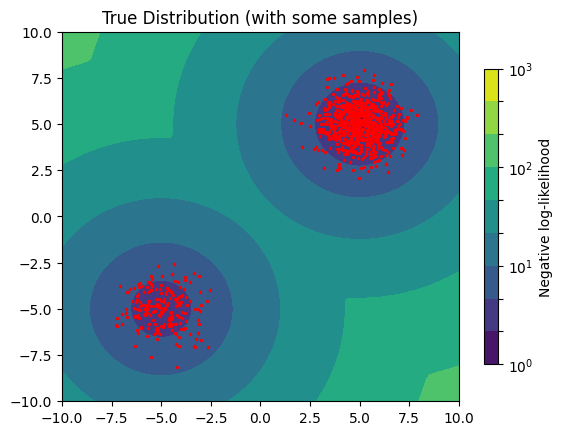

In [73]:
# ==========================================
# 2. Data Generation (Mixture of Gaussians)
# ==========================================
# Replicating the toy distribution from Section 3.2.1 
modes = torch.tensor([[-5., -5.], [5., 5.]])
weights = torch.tensor([0.2, 0.8])

def get_data(batch_size):
    # p_data = 1/5 N((-5,-5), I) + 4/5 N((5,5), I)
    
    # Categorical distribution to choose mode
    indices = torch.multinomial(weights, batch_size, replacement=True)
    
    # Sample from standard normal and shift/scale
    data = torch.randn(batch_size, 2) + modes[indices]
    return data

def log_prob(samples):
    gm1 = torch.distributions.multivariate_normal.MultivariateNormal(modes[0], torch.eye(2)).log_prob(samples) + torch.log(weights[0])
    gm2 = torch.distributions.multivariate_normal.MultivariateNormal(modes[1], torch.eye(2)).log_prob(samples) + torch.log(weights[1])
    return - torch.logsumexp(torch.stack([gm1, gm2], dim=0), dim=0)

# Show overlay of true distribution
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)
XX = np.array([X.ravel(), Y.ravel()]).T
Z = log_prob(torch.from_numpy(XX)).numpy().reshape(X.shape)
CS = plt.contourf(X, Y, Z, norm=matplotlib.colors.LogNorm(vmin=1.0, vmax=1000.0), levels=np.logspace(0, 3, 10), cmap='viridis')
plt.colorbar(CS, shrink=0.8, extend="both", label='Negative log-likelihood')

# Plot the original data points
data = get_data(1000).numpy()
plt.scatter(data[:,0], data[:,1], s=2, color='red')
plt.title('True Distribution (with some samples)')
plt.show()


In [ ]:
# ==========================================
# 3. Noise Conditional Score Network (NCSN)
# ==========================================
# A simple MLP that estimates gradients. Conditioned on sigma.
# The paper uses conditional instance norm for images, but for 2D data,
# concatenating sigma to the input is sufficient and effective.
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Input is x (2D) + sigma (1D)
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.Softplus(), # Softplus is smooth, good for derivatives [cite: 489]
            nn.Linear(128, 128),
            nn.Softplus(),
            nn.Linear(128, 2)
        )

    def forward(self, x, sigma):
        # We append sigma to x as a conditioning signal
        # Use log(sigma) for better numerical stability in conditioning
        sigma = sigma.view(-1, 1).expand(x.shape[0], 1)
        # Conditioning input: Concatenate x and log(sigma)
        in_features = torch.cat([x, torch.log(sigma)], dim=1)
        return self.net(in_features)

# Visualize the ScoreNet network
ScoreNet()        

ScoreNet(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Softplus(beta=1.0, threshold=20.0)
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Softplus(beta=1.0, threshold=20.0)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [ ]:
# ==========================================
# 4. Loss Function: Denoising Score Matching
# ==========================================
# Implements Equation (6) and (2) from the paper [cite: 65, 201, 204]
def compute_loss(model, x, sigmas):
    # 1. Select random sigma levels for this batch
    indices = torch.randint(0, len(sigmas), (x.shape[0],))
    used_sigmas = sigmas[indices].view(-1, 1)
    
    # 2. Perturb data with noise: x_tilde ~ N(x, sigma^2 I)
    noise = torch.randn_like(x) * used_sigmas
    x_tilde = x + noise
    
    # 3. Estimate score: s_theta(x_tilde, sigma)
    estimated_scores = model(x_tilde, used_sigmas)
    
    # 4. Target score: grad_x log q_sigma(x_tilde | x) = -(x_tilde - x) / sigma^2
    target_scores = -noise / (used_sigmas ** 2)
    
    # 5. Weighting function lambda(sigma) = sigma^2 [cite: 211]
    # Loss = (1/2) * || s_theta + (x_tilde - x)/sigma^2 ||^2 * sigma^2
    # Simplified: (1/2) * || s_theta * sigma + z ||^2 where z ~ N(0, I)
    
    # We use the explicit form multiplied by sigma^2 as derived in Eq 6 logic
    loss = 0.5 * ((estimated_scores - target_scores) ** 2).sum(dim=1) * (used_sigmas.squeeze() ** 2)
    
    return loss.mean()

In [57]:
# ==========================================
# 5. Annealed Langevin Dynamics Sampling
# ==========================================
# Implements Algorithm 1 from the paper [cite: 218]
def annealed_langevin_dynamics(model, sigmas, n_samples=1000, step_lr=2e-5, T=100):
    # 1. Initialize with random noise (Uniform or Normal)
    x = torch.rand(n_samples, 2) * 16 - 8 # Uniform [-8, 8]
    
    history = [x.clone().numpy()] # To visualize the process
    
    model.eval()
    with torch.no_grad():
        for i, sigma in enumerate(sigmas):
            # Step size alpha_i = epsilon * sigma_i^2 / sigma_L^2 [cite: 223]
            alpha = step_lr * (sigma / sigmas[-1]) ** 2
            
            for t in range(T):
                # Draw noise z_t ~ N(0, I)
                z_t = torch.randn_like(x)
                
                # Get score
                score = model(x, torch.full((n_samples,), sigma))
                
                # Update rule: x_t = x_{t-1} + (alpha/2) * score + sqrt(alpha) * z_t
                x = x + (alpha / 2) * score + torch.sqrt(alpha) * z_t
                
            # Save state after each noise level for visualization
            history.append(x.clone().numpy())
            
    return x, history

Training Score Network...
Iter 0: Loss = 40.1680
Iter 1000: Loss = 0.8106
Iter 2000: Loss = 0.8678
Iter 3000: Loss = 0.7291
Iter 4000: Loss = 0.6505
Iter 5000: Loss = 0.5797
Iter 6000: Loss = 0.6608
Iter 7000: Loss = 0.8090
Iter 8000: Loss = 0.7288
Iter 9000: Loss = 0.7188


Text(0.5, 1.0, 'Training Loss')

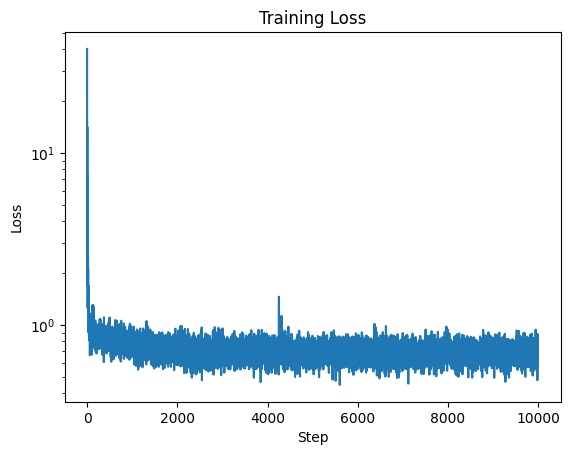

In [80]:
# ==========================================
# 6. Training & Visualization
# ==========================================

BATCH_SIZE = 128
LR = 0.002
ITERATIONS = 10000

# --- Training ---
print("Training Score Network...")
model = ScoreNet()
optimizer = optim.Adam(model.parameters(), lr=LR)

loss_history = []
for it in range(ITERATIONS):
    optimizer.zero_grad()
    data = get_data(BATCH_SIZE)
    loss = compute_loss(model, data, sigmas)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    
    if it % 1000 == 0:
        print(f"Iter {it}: Loss = {loss.item():.4f}")

ax = sns.lineplot(loss_history)
ax.set_yscale("log")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training Loss")

Generating Samples...


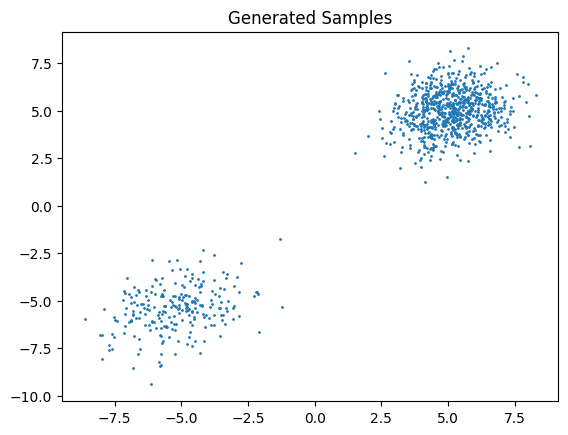

In [78]:

# --- Sampling ---
print("Generating Samples...")
final_samples, trajectory = annealed_langevin_dynamics(model, sigmas, n_samples=1000, T=100)

plt.scatter(final_samples[:, 0], final_samples[:, 1], s=1)
plt.title("Generated Samples")
plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1036336/2885896730.py:18: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Estimated Score Field (Small $\sigma$)")


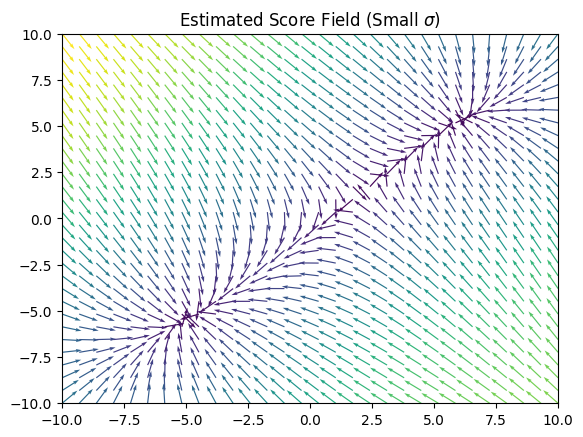

In [90]:

# 2. Estimated Vector Field (Score) at low noise level
grid_x = np.linspace(-10, 10, 30)
grid_y = np.linspace(-10, 10, 30)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
sigma_tensor = torch.full((grid_tensor.shape[0],), sigmas[-1]) # Lowest noise level

with torch.no_grad():
    scores = model(grid_tensor, sigma_tensor).numpy()

# Normalize arrows for better visualization
norm = np.linalg.norm(scores, axis=1, keepdims=True)
scores_norm = scores / (norm + 1e-5) 

plt.quiver(xx, yy, scores_norm[:, 0].reshape(30, 30), scores_norm[:, 1].reshape(30, 30), 
           norm.reshape(30, 30), cmap='viridis', scale=25)

plt.title("Estimated Score Field (Small $\sigma$)")
plt.xlim(-10, 10); plt.ylim(-10, 10)
plt.show()

In [88]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- Evolution Visualization (Animation) ---
print("Generating Samples...")
# Assuming 'model', 'sigmas', 'trajectory', and 'NUM_LEVELS' are already defined 
# from your previous logic.
final_samples, trajectory = annealed_langevin_dynamics(model, sigmas, n_samples=1000, T=100)

# 1. Setup the Figure and Axis
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.grid(True, alpha=0.2)

# 2. Initialize the Scatter Plot
# We create an empty scatter plot first. Note 'animated=True' helps with blitting.
scat = ax.scatter([], [], s=2, alpha=0.5, color='purple')
title_text = ax.text(0.5, 1.02, "", transform=ax.transAxes, ha="center", fontsize=12)

# 3. Define the Update Function
def update(frame):
    # 'frame' is the index representing the current step in the trajectory
    current_pts = trajectory[frame]
    
    # Update scatter positions efficiently
    scat.set_offsets(current_pts)
    
    # Update Title based on progress
    if frame == 0:
        title_text.set_text("Initial uniform random samples")
    else:
        # Note: frame-1 because trajectory[0] is noise, trajectory[1] corresponds to sigmas[0]
        current_sigma = sigmas[frame-1] if frame-1 < len(sigmas) else sigmas[-1]
        title_text.set_text(f"Step {frame}/{len(trajectory)-1}\n$\sigma \\approx {current_sigma:.2f}$")
    
    return scat, title_text

# 4. Create the Animation
# interval=50 means 50ms per frame (20 fps)
anim = FuncAnimation(fig, update, frames=len(trajectory), interval=1000, blit=True)

# 5. Display in Jupyter
plt.close() # Prevents the static text placeholder from showing up
HTML(anim.to_jshtml())

<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1036336/3422113425.py:36: SyntaxWarning: invalid escape sequence '\s'
  title_text.set_text(f"Step {frame}/{len(trajectory)-1}\n$\sigma \\approx {current_sigma:.2f}$")


Generating Samples...
